# Lab #4 Intensity Transformations and Filtering - Spatial Domain

Name: Maan Abdullah Alghamdi  
ID: 2240001433  
Course: ARTI 404 - Image Processing

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, io

img = data.moon()
reference = data.rocket()
source = data.chelsea()

os.makedirs("images", exist_ok=True)
io.imsave("images/moon.png", img)
io.imsave("images/rocket.png", reference)
io.imsave("images/chelsea.png", source)

for name, image in [("Moon", img), ("Rocket", reference), ("Chelsea", source)]:
    print(f"{name}: shape={image.shape}, dtype={image.dtype}, range=[{image.min()}, {image.max()}]")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

Moon: shape=(512, 512), dtype=uint8, range=[0, 255]
Rocket: shape=(427, 640, 3), dtype=uint8, range=[0, 255]
Chelsea: shape=(300, 451, 3), dtype=uint8, range=[0, 231]


## Procedural Task #1: Fixed thresholding
For each threshold $T$, a pixel becomes 255 (white) if its intensity is greater than $T$; otherwise, it becomes 0 (black). NumPy implements the same binary rule as `cv2.THRESH_BINARY`. The required thresholds are 0, 50, 100, 150, and 200.

T=  0: white pixels = 99.91%
T= 50: white pixels = 99.16%
T=100: white pixels = 93.93%
T=150: white pixels = 0.66%
T=200: white pixels = 0.16%


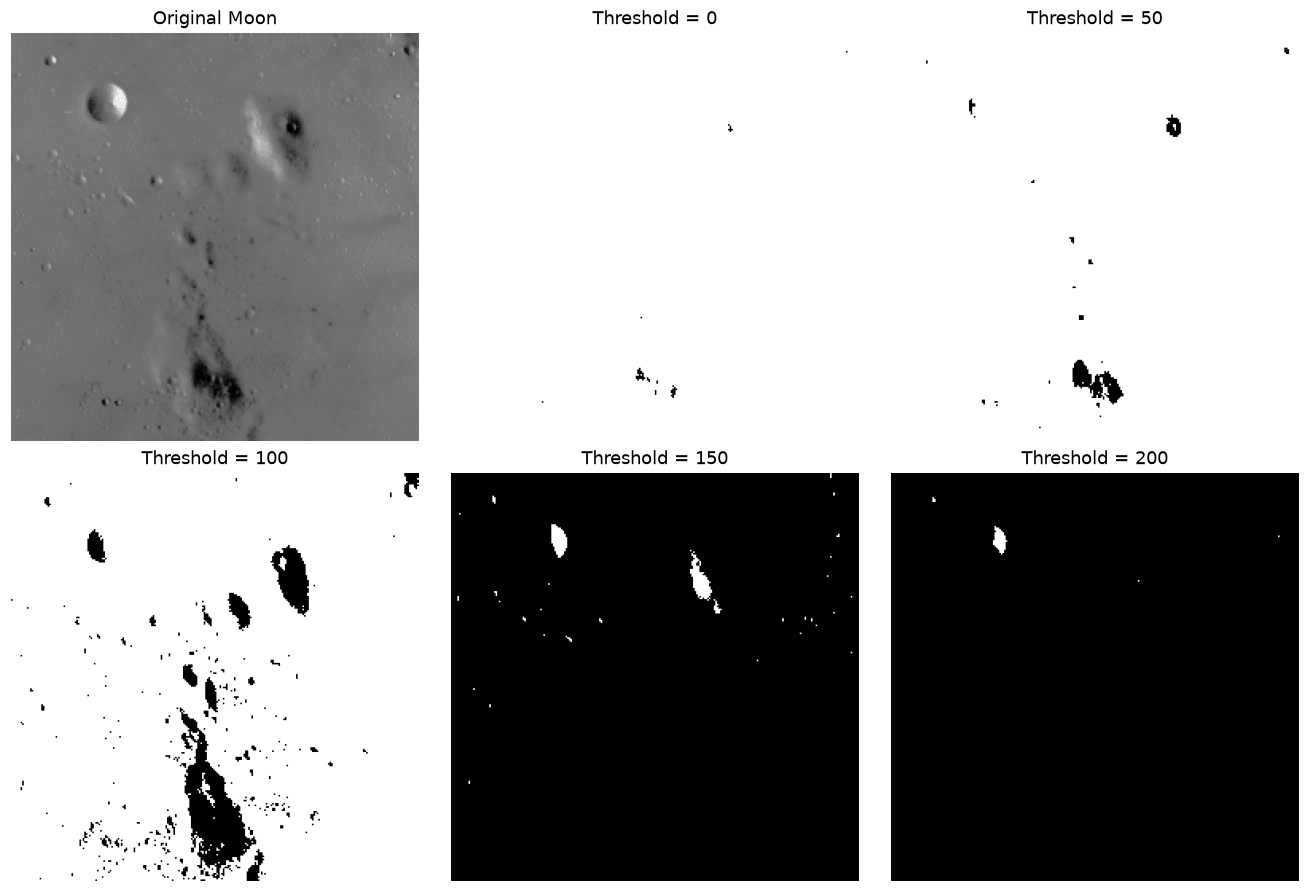

In [2]:
threshold_values = [0, 50, 100, 150, 200]
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Moon")
thresholded_images = []
for ax, threshold_value in zip(axes[1:], threshold_values):
    binary = np.where(img > threshold_value, 255, 0).astype(np.uint8)
    thresholded_images.append(binary)
    ax.imshow(binary, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Threshold = {threshold_value}")
    print(f"T={threshold_value:3d}: white pixels = {np.mean(binary == 255):.2%}")
for ax in axes:
    ax.axis("off")
plt.show()

**Observation:** Increasing the threshold reduces the white foreground. Low thresholds retain most pixels, while high thresholds retain only the brightest regions. A fixed threshold is sensitive to the image intensity distribution.

## Procedural Task #2: Contrast stretching at the 2nd and 98th percentiles
The lower and upper percentile intensities are mapped to 0 and 255. Intensities outside this interval are clipped. Images use a fixed display range so the contrast comparison is meaningful.

2nd percentile = 78.00; 98th percentile = 129.00


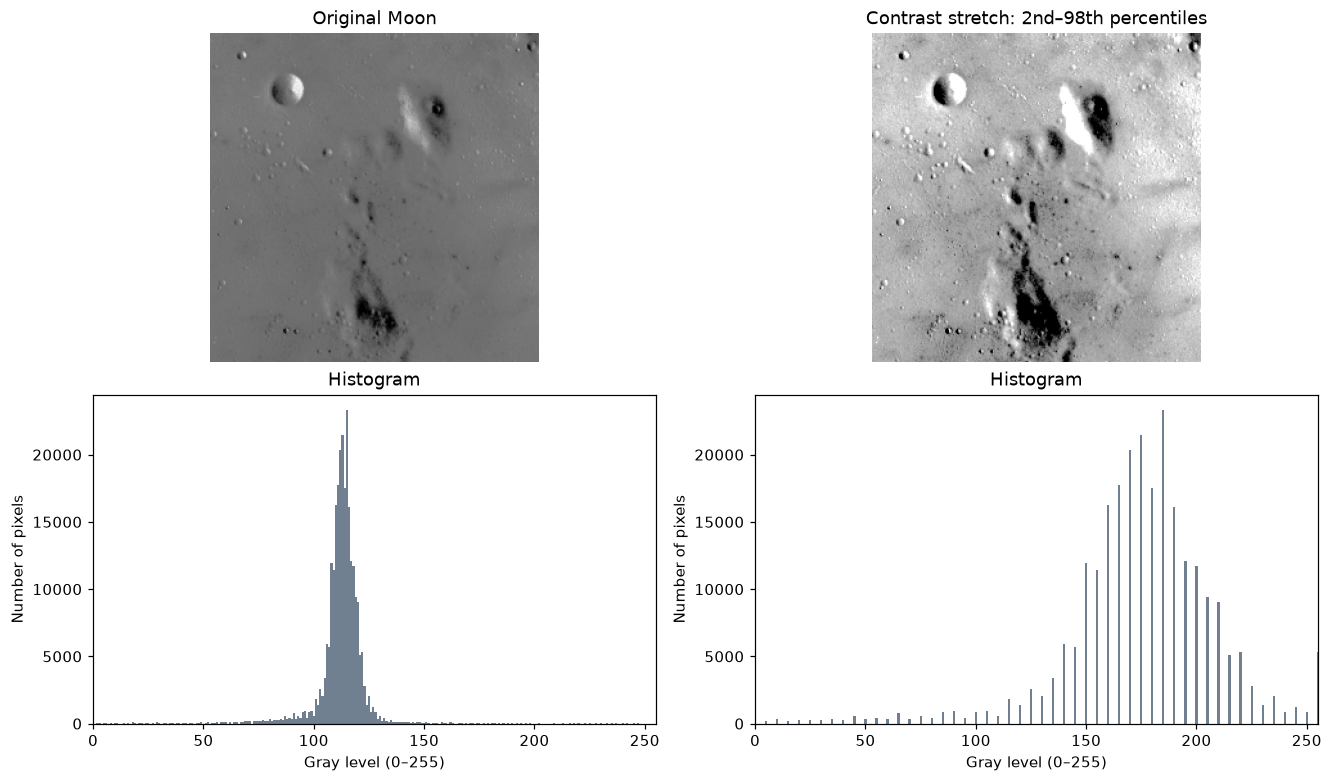

In [3]:
def show_gray_hist(images, titles, normalized=False):
    fig, axes = plt.subplots(2, len(images), figsize=(6 * len(images), 7),
                             squeeze=False, constrained_layout=True)
    upper = 1 if normalized else 255
    edges = np.linspace(0, 1, 257) if normalized else np.arange(257) - 0.5
    for col, (image, title) in enumerate(zip(images, titles)):
        axes[0, col].imshow(image, cmap="gray", vmin=0, vmax=upper)
        axes[0, col].set_title(title)
        axes[0, col].axis("off")
        axes[1, col].hist(image.ravel(), bins=edges, color="slategray")
        axes[1, col].set(xlabel="Intensity (0–1)" if normalized else "Gray level (0–255)",
                         ylabel="Number of pixels", xlim=(0, upper), title="Histogram")
    plt.show()

p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
print(f"2nd percentile = {p2:.2f}; 98th percentile = {p98:.2f}")
show_gray_hist([img, img_rescale], ["Original Moon", "Contrast stretch: 2nd–98th percentiles"])

**Observation:** Stretching spreads the central intensity range across the full grayscale range, making lunar surface detail more distinct. Pixels below the lower bound become black, and pixels above the upper bound become white.

## Assessment Task #1: Contrast stretching at the 3rd and 80th percentiles
Apply the same method with the requested percentile bounds, then display the image and its histogram.

3rd percentile = 87.00; 80th percentile = 118.00
Pixels at or above the upper bound: 21.01%


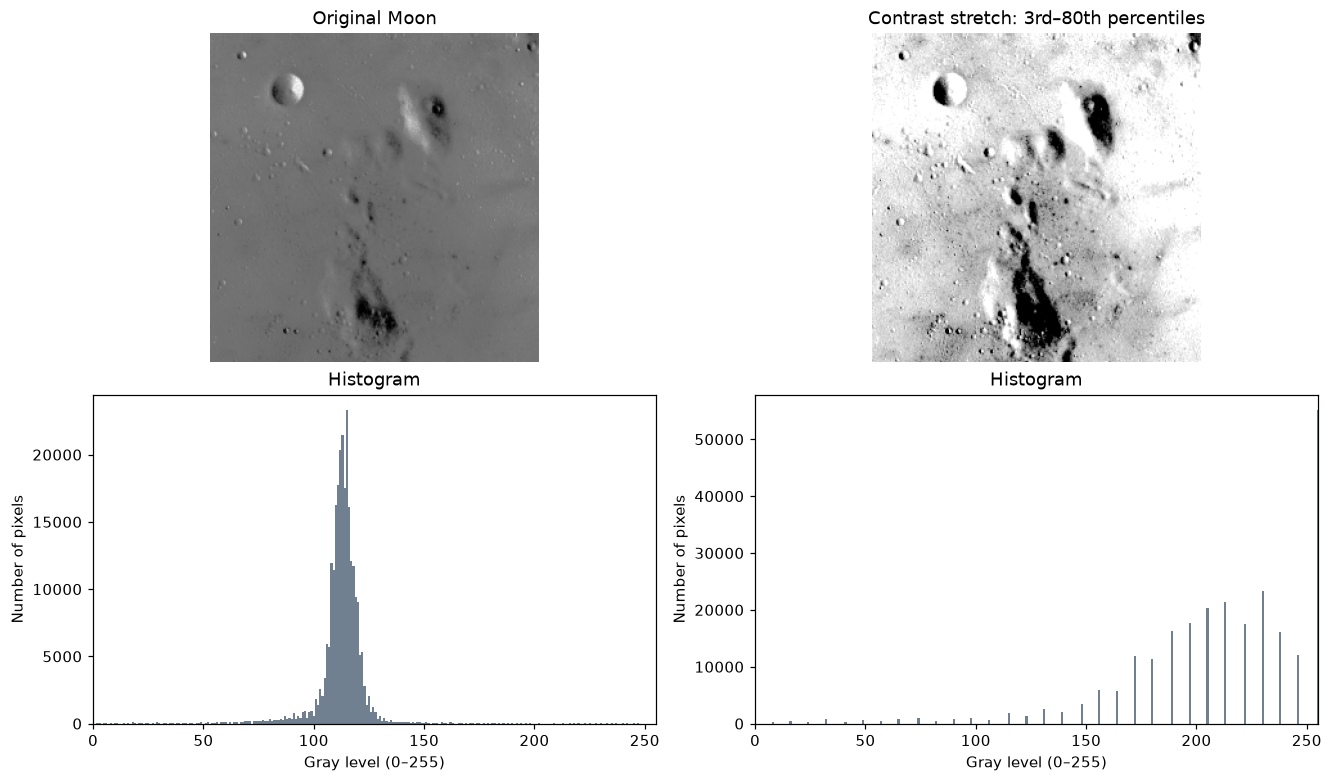

In [4]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))
print(f"3rd percentile = {p3:.2f}; 80th percentile = {p80:.2f}")
print(f"Pixels at or above the upper bound: {np.mean(img >= p80):.2%}")
show_gray_hist([img, img_rescale_3_80], ["Original Moon", "Contrast stretch: 3rd–80th percentiles"])

**Observation:** The 80th-percentile upper bound saturates a larger fraction of bright pixels than the 98th-percentile bound. This increases contrast in the retained interval but removes differences among brighter pixels, producing a prominent histogram count at 255. Tied integer intensities mean the saturated fraction need not be exactly 20%.

## Assessment Task #2: Histogram equalization
`exposure.equalize_hist` uses the cumulative intensity distribution to redistribute intensities. Its output is floating point in the range 0–1, so the histogram and image display use that range. Histogram equalization aims to spread intensities; it does not guarantee a perfectly flat histogram for a discrete image.

Equalized image: dtype=float64, range=[0.000916, 1.000000]


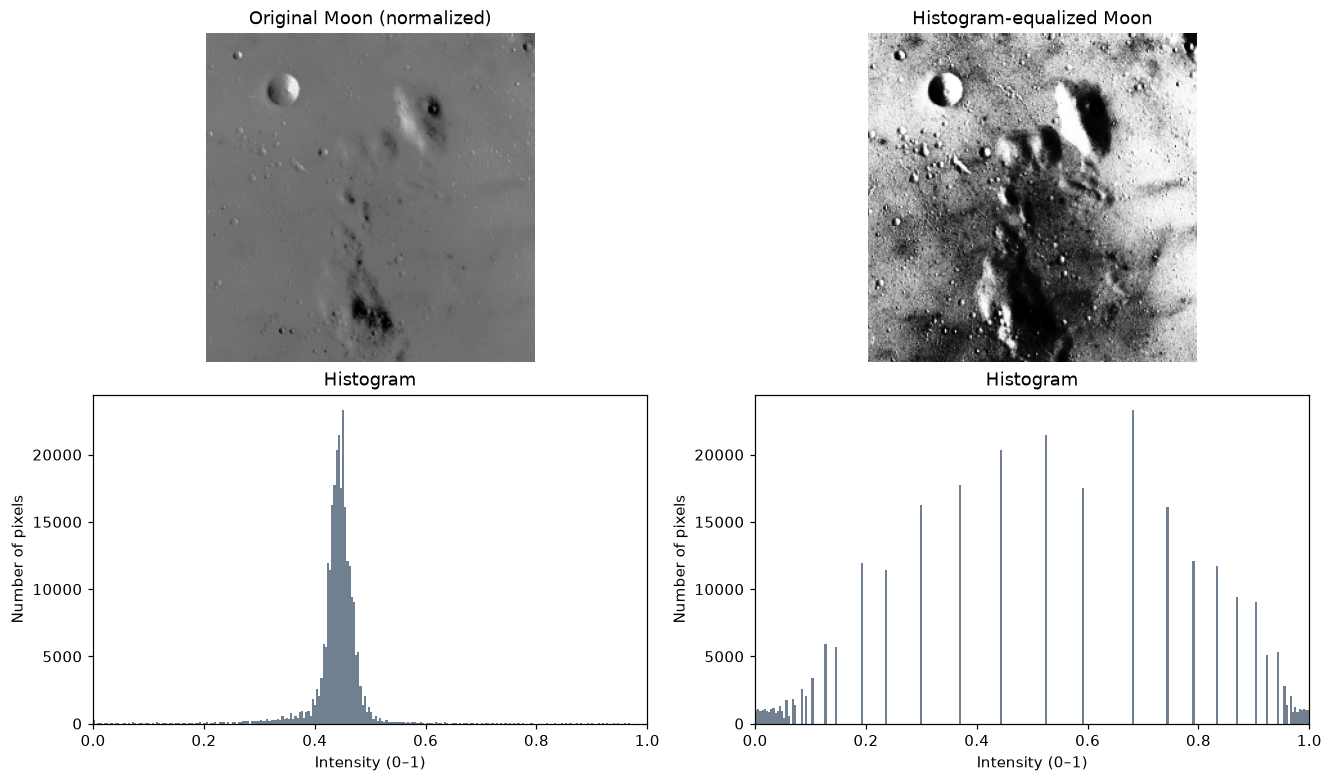

In [5]:
img_equalized = exposure.equalize_hist(img)
print(f"Equalized image: dtype={img_equalized.dtype}, range=[{img_equalized.min():.6f}, {img_equalized.max():.6f}]")
show_gray_hist([img / 255.0, img_equalized],
               ["Original Moon (normalized)", "Histogram-equalized Moon"], normalized=True)

**Observation:** Equalization spreads the heavily populated middle intensities and reveals surface variations. Gaps and spikes remain because pixels with the same original intensity receive the same output value. Unlike percentile stretching, equalization uses a nonlinear mapping determined by the cumulative histogram.

## Assessment Task #3: Histogram matching
Chelsea is the source and Rocket is the reference. Matching is applied independently to the red, green, and blue channels using `channel_axis=-1`. The images do not need equal dimensions because matching compares intensity distributions, not pixel positions.

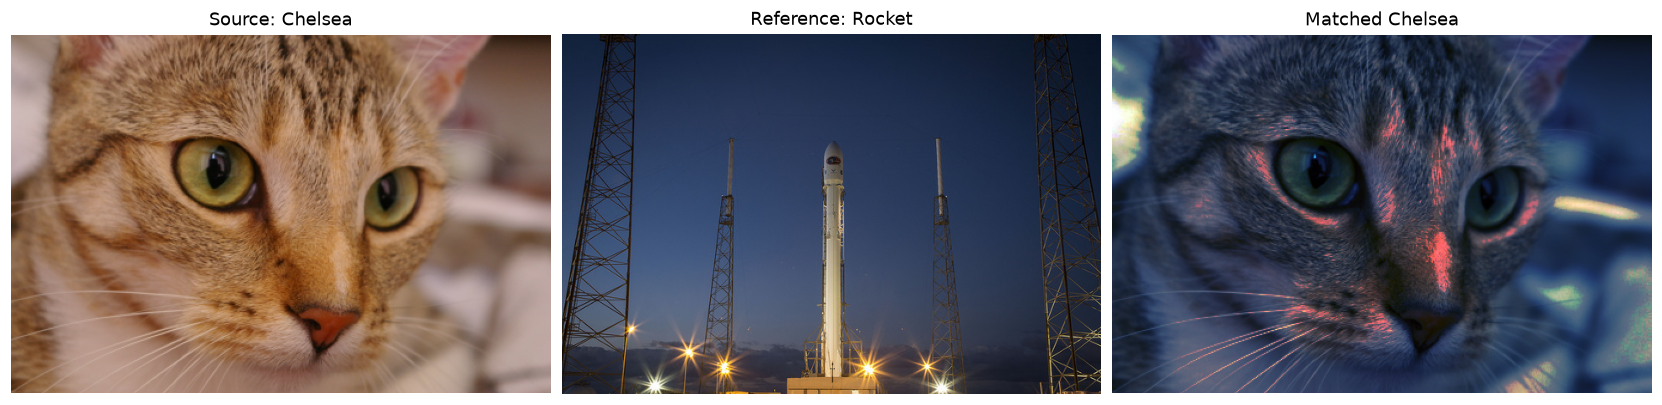

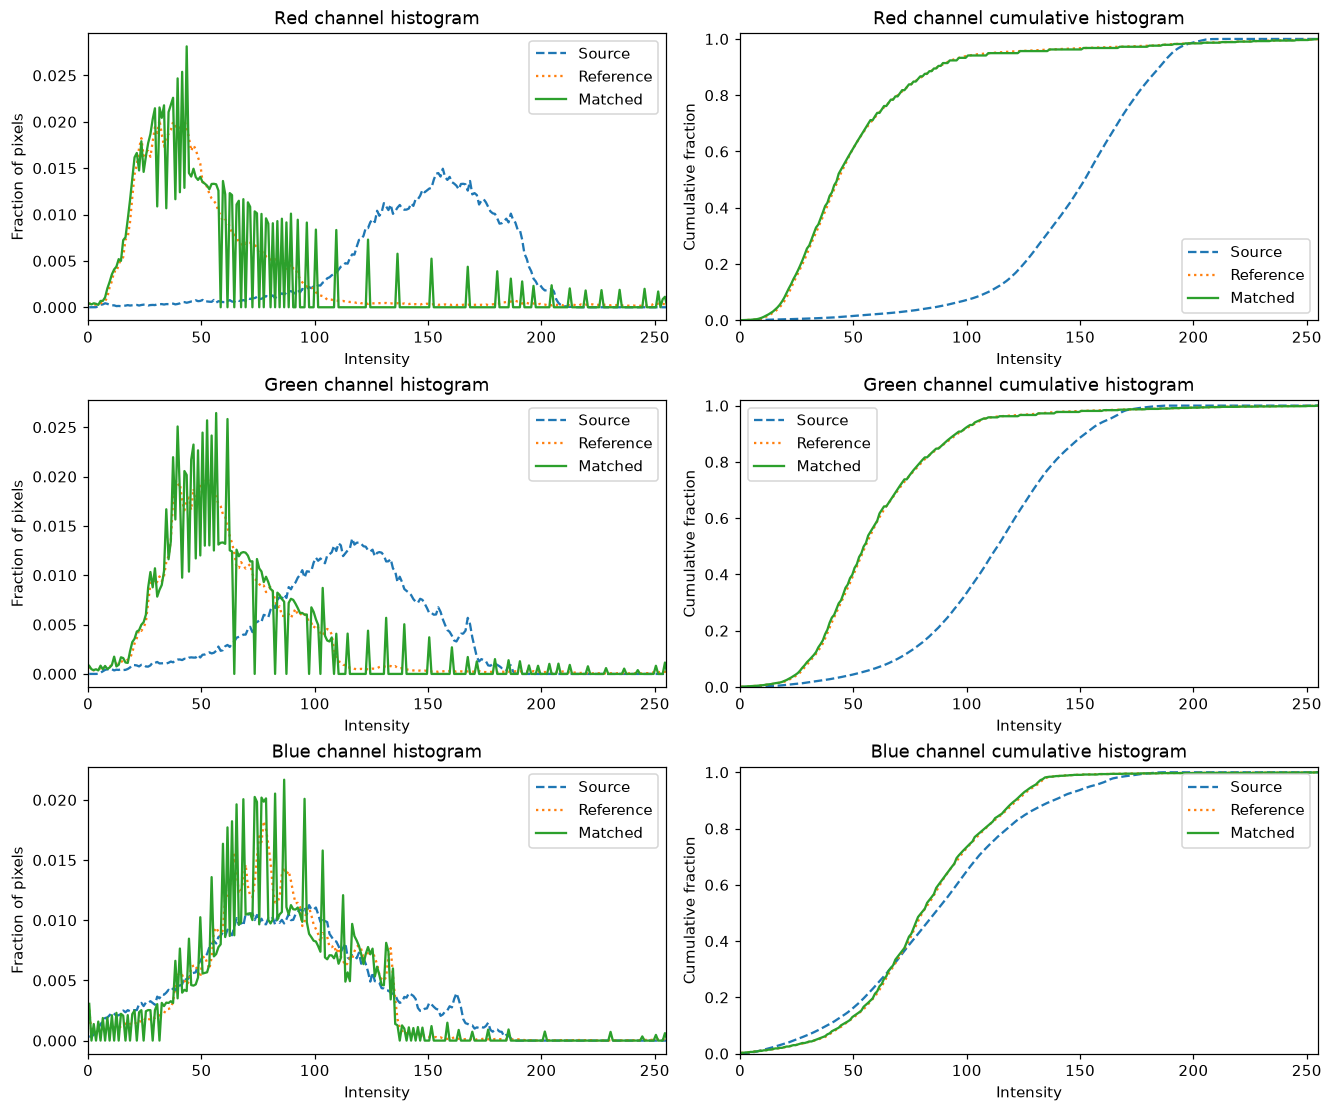

In [6]:
matched = exposure.match_histograms(source, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, image, title in zip(axes,
                           [source / 255.0, reference / 255.0, np.clip(matched / 255.0, 0, 1)],
                           ["Source: Chelsea", "Reference: Rocket", "Matched Chelsea"]):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")
plt.show()

# Normalize counts because the source and reference contain different numbers of pixels.
fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
for channel, color in enumerate(["red", "green", "blue"]):
    for image, label, style in [(source, "Source", "--"),
                                (reference, "Reference", ":"),
                                (matched, "Matched", "-")]:
        counts, edges = np.histogram(image[..., channel], bins=256, range=(0, 256))
        centers = (edges[:-1] + edges[1:]) / 2
        probability = counts / counts.sum()
        axes[channel, 0].plot(centers, probability, linestyle=style, label=label)
        axes[channel, 1].plot(centers, np.cumsum(probability), linestyle=style, label=label)
    axes[channel, 0].set(title=f"{color.capitalize()} channel histogram",
                         xlabel="Intensity", ylabel="Fraction of pixels", xlim=(0, 255))
    axes[channel, 1].set(title=f"{color.capitalize()} channel cumulative histogram",
                         xlabel="Intensity", ylabel="Cumulative fraction", xlim=(0, 255), ylim=(0, 1.02))
    for ax in axes[channel]:
        ax.legend()
plt.show()

**Observation:** The matched Chelsea image retains its spatial content while its colors and brightness shift toward Rocket. The per-channel cumulative curves provide a clearer comparison than raw histogram spikes. Matching is approximate because the images have discrete intensities and different sample counts; independent channel matching can also change color relationships.

In [7]:
# Check the key properties of the computed results.
assert all(set(np.unique(x)).issubset({0, 255}) for x in thresholded_images)
assert img_rescale.shape == img.shape == img_rescale_3_80.shape
assert img_rescale_3_80.min() == 0 and img_rescale_3_80.max() == 255
assert 0 <= img_equalized.min() <= img_equalized.max() <= 1
assert matched.shape == source.shape and np.isfinite(matched).all()
print("All result checks passed.")

All result checks passed.
